# Biblioteca UNDAC — Análisis exploratorio de afluencia

Este notebook corresponde a la **Etapa 2**. Valida el dataset sintético, analiza sus patrones, realiza una división temporal 80/20 y crea los niveles **Bajo, Medio y Alto** sin usar información del futuro.

> Los resultados son experimentales porque el dataset es sintético. El mismo pipeline deberá ejecutarse nuevamente con los datos institucionales reales.

## 1. Librerías y carga del dataset

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

ruta = Path('ml/data/dataset_afluencia_sintetico.csv')
if not ruta.exists():
    ruta = Path('dataset_afluencia_sintetico.csv')

if not ruta.exists():
    try:
        from google.colab import files
        print('Selecciona dataset_afluencia_sintetico.csv')
        cargados = files.upload()
        ruta = Path(next(nombre for nombre in cargados if nombre.lower().endswith('.csv')))
    except (ImportError, StopIteration):
        raise FileNotFoundError('No se encontró el CSV. Súbelo a Colab y vuelve a ejecutar esta celda.')

df = pd.read_csv(ruta, encoding='utf-8-sig')
print(f'Archivo: {ruta}')
print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
display(df.head())

Selecciona dataset_afluencia_sintetico.csv


Saving dataset_afluencia_sintetico.csv to dataset_afluencia_sintetico.csv
Archivo: dataset_afluencia_sintetico.csv
Dimensiones: 10,218 filas x 12 columnas


,Fecha,Hora,Sede,CantidadIngresos,DiaSemana,NumeroDiaSemana,Mes,EsFinSemana,EsFeriado,EsVacaciones,PeriodoAcademico,EsSintetico
0,2026-03-02,8,Central,0,Lunes,0,3,0,0,0,Inicio de semestre,1
1,2026-03-02,9,Central,3,Lunes,0,3,0,0,0,Inicio de semestre,1
2,2026-03-02,10,Central,14,Lunes,0,3,0,0,0,Inicio de semestre,1
3,2026-03-02,11,Central,17,Lunes,0,3,0,0,0,Inicio de semestre,1
4,2026-03-02,12,Central,6,Lunes,0,3,0,0,0,Inicio de semestre,1


## 2. Validación de estructura y calidad

In [2]:
columnas_esperadas = [
    'Fecha', 'Hora', 'Sede', 'CantidadIngresos', 'DiaSemana',
    'NumeroDiaSemana', 'Mes', 'EsFinSemana', 'EsFeriado',
    'EsVacaciones', 'PeriodoAcademico', 'EsSintetico'
]
assert list(df.columns) == columnas_esperadas, 'Las columnas no coinciden con la estructura requerida.'

df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
columnas_enteras = ['Hora', 'CantidadIngresos', 'NumeroDiaSemana', 'Mes',
                     'EsFinSemana', 'EsFeriado', 'EsVacaciones', 'EsSintetico']
for columna in columnas_enteras:
    df[columna] = pd.to_numeric(df[columna], errors='coerce')

duplicados = df.duplicated(subset=['Fecha', 'Hora', 'Sede']).sum()
nulos = df.isna().sum()
assert df['Fecha'].notna().all(), 'Existen fechas inválidas.'
assert (df['CantidadIngresos'] >= 0).all(), 'Existen cantidades negativas.'
assert df['Hora'].between(8, 20).all(), 'Existen horas fuera del horario definido.'
assert duplicados == 0, 'Existen combinaciones repetidas de fecha, hora y sede.'

print('Estructura correcta')
print(f'Duplicados fecha-hora-sede: {duplicados}')
print(f'Nulos totales: {int(nulos.sum())}')
print(f'Periodo: {df.Fecha.min().date()} a {df.Fecha.max().date()}')
print(f'Fechas con atención: {df.Fecha.nunique()}')
print(f'Sedes: {df.Sede.nunique()}')

Estructura correcta
Duplicados fecha-hora-sede: 0
Nulos totales: 0
Periodo: 2026-03-02 a 2026-08-31
Fechas con atención: 131
Sedes: 6


In [3]:
resumen_sedes = (df.groupby('Sede')['CantidadIngresos']
                   .agg(Observaciones='size', Total='sum', Promedio='mean', Mediana='median', Maximo='max')
                   .sort_values('Promedio', ascending=False)
                   .round(2))
display(resumen_sedes)

,Observaciones,Total,Promedio,Mediana,Maximo
Sede,,,,,
Central,1703,16317,9.58,8.0,35
Tarma,1703,9518,5.59,5.0,26
La Merced,1703,8791,5.16,4.0,20
Oxapampa,1703,6801,3.99,3.0,20
Yanahuanca,1703,5765,3.39,3.0,17
Paucartambo,1703,5044,2.96,2.0,17


## 3. Patrones por hora y sede

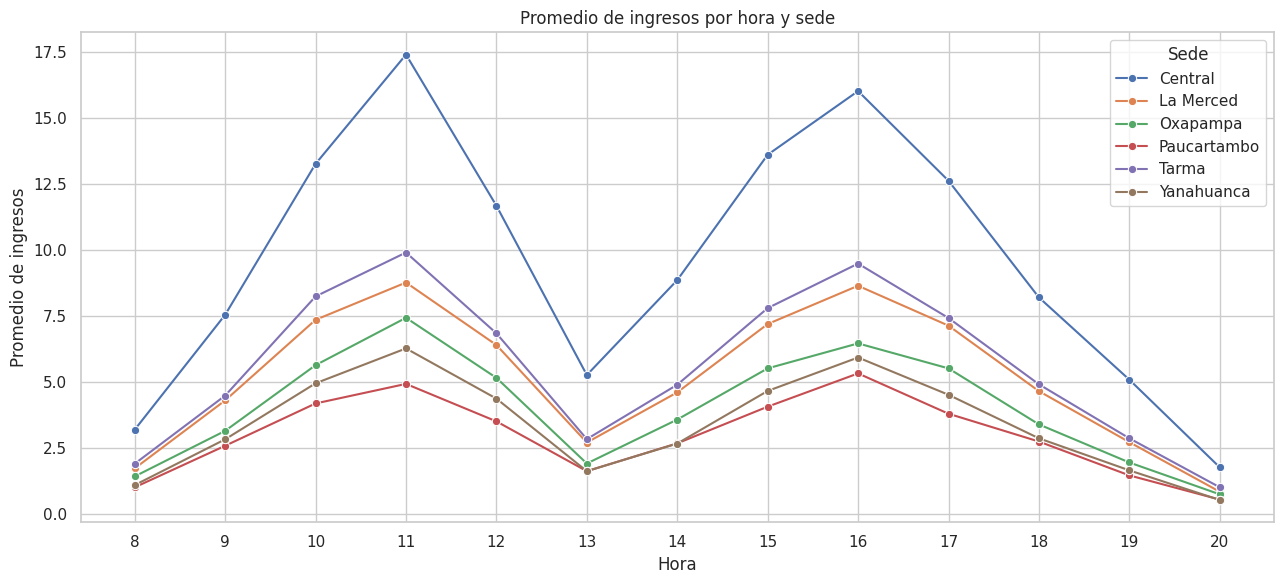

In [4]:
promedio_hora_sede = (df.groupby(['Hora', 'Sede'], as_index=False)['CantidadIngresos'].mean())
plt.figure(figsize=(13, 6))
sns.lineplot(data=promedio_hora_sede, x='Hora', y='CantidadIngresos', hue='Sede', marker='o')
plt.title('Promedio de ingresos por hora y sede')
plt.ylabel('Promedio de ingresos')
plt.xticks(range(8, 21))
plt.tight_layout()
plt.show()

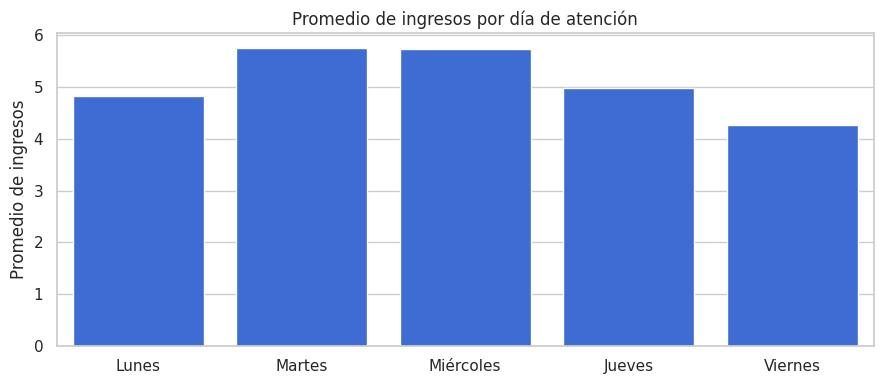

In [5]:
promedio_dia = (df.groupby(['NumeroDiaSemana', 'DiaSemana'], as_index=False)['CantidadIngresos'].mean()
                  .sort_values('NumeroDiaSemana'))
plt.figure(figsize=(9, 4))
sns.barplot(data=promedio_dia, x='DiaSemana', y='CantidadIngresos', color='#2563eb')
plt.title('Promedio de ingresos por día de atención')
plt.ylabel('Promedio de ingresos')
plt.xlabel('')
plt.tight_layout()
plt.show()

## 4. División temporal 80/20

No se utiliza una división aleatoria. Las fechas más antiguas forman el entrenamiento y las más recientes forman la prueba.

In [6]:
fechas = sorted(df['Fecha'].drop_duplicates())
posicion_corte = max(1, int(len(fechas) * 0.80))
fecha_corte = fechas[posicion_corte - 1]

train = df[df['Fecha'] <= fecha_corte].copy()
test = df[df['Fecha'] > fecha_corte].copy()

assert not train.empty and not test.empty
assert train['Fecha'].max() < test['Fecha'].min()

print(f'Fecha de corte: {fecha_corte.date()}')
print(f'Entrenamiento: {len(train):,} filas ({train.Fecha.min().date()} a {train.Fecha.max().date()})')
print(f'Prueba: {len(test):,} filas ({test.Fecha.min().date()} a {test.Fecha.max().date()})')
print(f'Proporción de entrenamiento: {len(train) / len(df):.2%}')

Fecha de corte: 2026-07-23
Entrenamiento: 8,112 filas (2026-03-02 a 2026-07-23)
Prueba: 2,106 filas (2026-07-24 a 2026-08-31)
Proporción de entrenamiento: 79.39%


## 5. Creación de niveles sin fuga de datos

Los umbrales se calculan **solo con entrenamiento** y por sede, porque las filiales tienen escalas de afluencia diferentes. La cantidad de ingresos se usa para crear la etiqueta, pero no será una entrada del modelo.

In [7]:
base_umbrales = train[train['EsFeriado'] == 0]
umbrales = (base_umbrales.groupby('Sede')['CantidadIngresos']
            .quantile([0.33, 0.67])
            .unstack()
            .rename(columns={0.33: 'UmbralBajo', 0.67: 'UmbralAlto'}))

umbrales['UmbralBajo'] = umbrales['UmbralBajo'].round(2)
umbrales['UmbralAlto'] = umbrales['UmbralAlto'].round(2)
display(umbrales)

,UmbralBajo,UmbralAlto
Sede,,
Central,7.0,14.0
La Merced,4.0,7.0
Oxapampa,3.0,6.0
Paucartambo,2.0,4.0
Tarma,4.0,8.0
Yanahuanca,2.0,5.0


In [8]:
def asignar_nivel(fila):
    limite_bajo = umbrales.loc[fila['Sede'], 'UmbralBajo']
    limite_alto = umbrales.loc[fila['Sede'], 'UmbralAlto']
    if fila['CantidadIngresos'] <= limite_bajo:
        return 'Bajo'
    if fila['CantidadIngresos'] <= limite_alto:
        return 'Medio'
    return 'Alto'

train['NivelAfluencia'] = train.apply(asignar_nivel, axis=1)
test['NivelAfluencia'] = test.apply(asignar_nivel, axis=1)

distribucion = pd.concat([
    train['NivelAfluencia'].value_counts().rename('Entrenamiento'),
    test['NivelAfluencia'].value_counts().rename('Prueba')
], axis=1).fillna(0).astype(int).reindex(['Bajo', 'Medio', 'Alto'])
distribucion['Entrenamiento_%'] = (distribucion['Entrenamiento'] / len(train) * 100).round(2)
distribucion['Prueba_%'] = (distribucion['Prueba'] / len(test) * 100).round(2)
display(distribucion)

,Entrenamiento,Prueba,Entrenamiento_%,Prueba_%
NivelAfluencia,,,,
Bajo,3507,1499,43.23,71.18
Medio,2353,459,29.01,21.79
Alto,2252,148,27.76,7.03


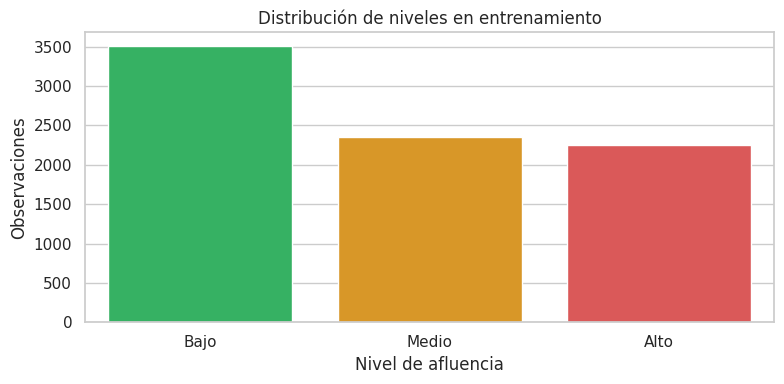

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=train, x='NivelAfluencia', order=['Bajo', 'Medio', 'Alto'],
              palette=['#22c55e', '#f59e0b', '#ef4444'], hue='NivelAfluencia', legend=False)
plt.title('Distribución de niveles en entrenamiento')
plt.xlabel('Nivel de afluencia')
plt.ylabel('Observaciones')
plt.tight_layout()
plt.show()

## 6. Variables autorizadas para el modelo

In [10]:
variables_modelo = [
    'Hora', 'Sede', 'NumeroDiaSemana', 'Mes',
    'EsFeriado', 'EsVacaciones', 'PeriodoAcademico'
]
variable_objetivo = 'NivelAfluencia'
variables_excluidas = ['Fecha', 'CantidadIngresos', 'DiaSemana', 'EsFinSemana', 'EsSintetico']

X_train = train[variables_modelo].copy()
y_train = train[variable_objetivo].copy()
X_test = test[variables_modelo].copy()
y_test = test[variable_objetivo].copy()

assert 'CantidadIngresos' not in X_train.columns
print('Variables de entrada:', variables_modelo)
print('Variable objetivo:', variable_objetivo)
print('Variables excluidas:', variables_excluidas)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)

Variables de entrada: ['Hora', 'Sede', 'NumeroDiaSemana', 'Mes', 'EsFeriado', 'EsVacaciones', 'PeriodoAcademico']
Variable objetivo: NivelAfluencia
Variables excluidas: ['Fecha', 'CantidadIngresos', 'DiaSemana', 'EsFinSemana', 'EsSintetico']
X_train: (8112, 7) | X_test: (2106, 7)
